In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
order_items_mart = pd.read_csv("../data/processed/order_items_mart.csv")

Сначала считаем базовые метрики по заказам: общее количество заказов, количество доставленных и отменённых заказов, а также их доли. будем считать коли чество уникальных заказов, так как логика заказова такая: один товар - один заказ

In [4]:
total_orders = len(order_items_mart["order_id"].unique())
total_orders

98666

In [5]:
delivered_orders = len(order_items_mart[order_items_mart["order_status"] == "delivered"]["order_id"].unique())
delivered_orders

96478

In [6]:
canceled_orders = len(order_items_mart[order_items_mart["order_status"] == "canceled"]["order_id"].unique())
canceled_orders

461

In [7]:
delivered_rate = delivered_orders / total_orders
canceled_rate = canceled_orders / total_orders

In [8]:
orders_kpi = pd.DataFrame({
    "metric": ["Total Orders", "Delivered Orders", "Canceled Orders", "Delivered Rate", "Canceled Rate"],
    "value": [total_orders, delivered_orders, canceled_orders, delivered_rate, canceled_rate]
})
orders_kpi

,metric,value
0,Total Orders,98666.000000
1,Delivered Orders,96478.000000
2,Canceled Orders,461.000000
3,Delivered Rate,0.977824
4,Canceled Rate,0.004672


In [9]:
unique_customers = order_items_mart["customer_unique_id"].nunique()
total_sellers = order_items_mart["seller_id"].nunique()
total_products = order_items_mart["product_id"].nunique()
total_categories = order_items_mart["product_category_name_english"].nunique()
total_items = len(order_items_mart)

In [10]:
kpi = pd.DataFrame({
    "metric": ["Unique Customers", "Total Sellers", "Total Products", "Total Categories", "Total Order Items"],
    "value": [unique_customers, total_sellers, total_products, total_categories, total_items]
})
kpi

,metric,value
0,Unique Customers,95420
1,Total Sellers,3095
2,Total Products,32951
3,Total Categories,72
4,Total Order Items,112650


In [11]:
revenue = order_items_mart["price"].sum()
freight_revenue = order_items_mart["freight_value"].sum()
gmv = order_items_mart["item_total"].sum()
aov = revenue / total_orders
avg_item_price = order_items_mart["price"].mean()
avg_freight_value = order_items_mart["freight_value"].mean()
freight_share = freight_revenue / gmv

In [12]:
financial_kpi = pd.DataFrame({
    "metric": ["Revenue", "Freight Revenue", "GMV", "AOV", "Average Item Price", "Average Freight Value","Freight Share"],
    "value": [revenue, freight_revenue, gmv, aov, avg_item_price, avg_freight_value, freight_share]
})
financial_kpi

,metric,value
0,Revenue,1.359164e+07
1,Freight Revenue,2.251910e+06
2,GMV,1.584355e+07
3,AOV,1.377541e+02
4,Average Item Price,1.206537e+02
5,Average Freight Value,1.999032e+01
6,Freight Share,1.421341e-01


In [13]:
avg_review_score = order_items_mart["review_score"].mean()
csat = order_items_mart["positive_review"].mean()
negative_review_rate = order_items_mart["negative_review"].mean()
one_star_rate = (order_items_mart["review_score"] == 1).mean()
avg_delivery_days = order_items_mart["delivery_days"].mean()
median_delivery_days = order_items_mart["delivery_days"].median()
late_delivery_rate = order_items_mart[order_items_mart["order_status"] == "delivered"]["is_late"].mean()

In [14]:
delivery_kpi = pd.DataFrame({
    "metric": ["Average Review Score", "CSAT", "Negative Review Rate", "One-star Rate", "Average Delivery Days", "Median Delivery Days", "Late Delivery Rate"],
    "value": [avg_review_score, csat, negative_review_rate, one_star_rate, avg_delivery_days, median_delivery_days, late_delivery_rate]
})

delivery_kpi

,metric,value
0,Average Review Score,4.032854
1,CSAT,0.755076
2,Negative Review Rate,0.161000
3,One-star Rate,0.125539
4,Average Delivery Days,12.007723
5,Median Delivery Days,10.000000
6,Late Delivery Rate,0.073922


In [15]:
overview_kpis = pd.concat([
    orders_kpi.rename(columns={"value": "order_value"}).assign(category="Orders"),
    kpi.rename(columns={"value": "order_value"}).assign(category="Entities"),
    financial_kpi.rename(columns={"value": "order_value"}).assign(category="Finance"),
    delivery_kpi.rename(columns={"value": "order_value"}).assign(category="Delivery")
])
overview_kpis

,metric,order_value,category
0,Total Orders,9.866600e+04,Orders
1,Delivered Orders,9.647800e+04,Orders
2,Canceled Orders,4.610000e+02,Orders
3,Delivered Rate,9.778242e-01,Orders
4,Canceled Rate,4.672329e-03,Orders
0,Unique Customers,9.542000e+04,Entities
1,Total Sellers,3.095000e+03,Entities
2,Total Products,3.295100e+04,Entities
3,Total Categories,7.200000e+01,Entities
4,Total Order Items,1.126500e+05,Entities


In [16]:
order_items_mart['order_purchase_timestamp'] = pd.to_datetime(order_items_mart['order_purchase_timestamp'])
order_items_mart['order_month_date'] = order_items_mart['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

orders_by_month = order_items_mart.groupby("order_month_date", as_index=False).agg(orders_count=("order_id", "nunique"))

orders_by_month_clean = orders_by_month[(orders_by_month["order_month_date"] > orders_by_month["order_month_date"].min()) & (orders_by_month["order_month_date"] < orders_by_month["order_month_date"].max())]

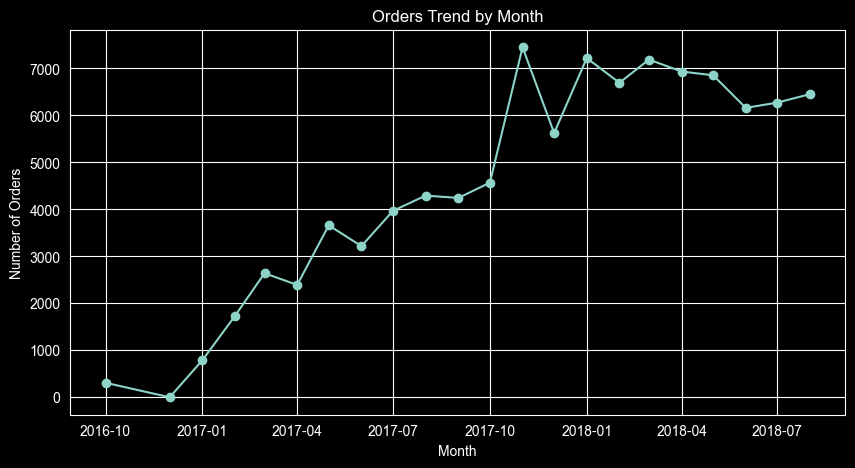

In [17]:
plt.figure(figsize=(10,5))
plt.plot(orders_by_month_clean["order_month_date"], orders_by_month_clean["orders_count"], marker="o")
plt.title("Orders Trend by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

Мы исключили первый и последний месяц, так как значений там не было и это мешало бы анализу

### Revenue Trend by Month

In [18]:
revenue_by_month = (order_items_mart.groupby("order_month_date", as_index=False).agg(revenue=("price", "sum")))
revenue_by_month_clean = revenue_by_month[(revenue_by_month["order_month_date"] > revenue_by_month["order_month_date"].min()) &(revenue_by_month["order_month_date"] < revenue_by_month["order_month_date"].max())]

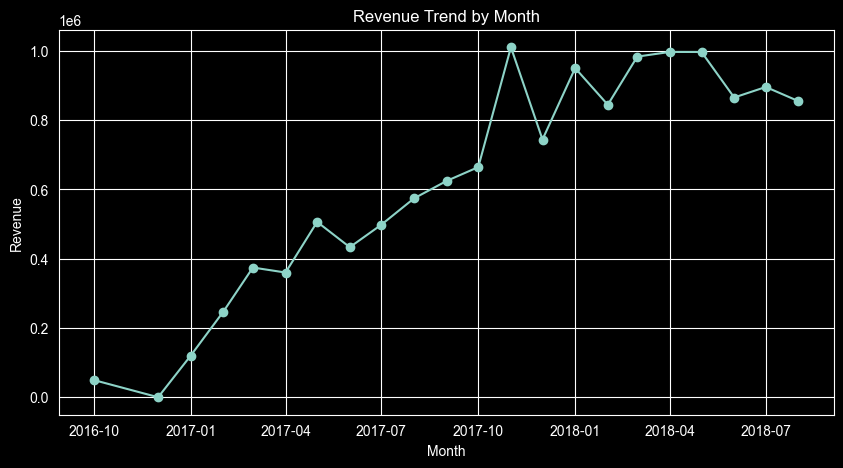

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(revenue_by_month_clean["order_month_date"], revenue_by_month_clean["revenue"], marker="o")
plt.title("Revenue Trend by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

Выручка росла вместе с количеством заказов: в течение 2017 года наблюдается устойчивый рост, а к концу 2017 - началу 2018 года бизнес выходит на уровень около 0.8–1.0 млн выручки в месяц.
Динамика выручки в целом повторяет динамику заказов, что говорит о том, что рост бизнеса в основном связан с ростом количества заказов. После пиковых месяцев в 2018 году заметно небольшое снижение, которое стоит дополнительно проверить через средний чек и категории.

In [20]:
monthly_metrics = (order_items_mart.groupby("order_month_date", as_index=False).agg(orders_count=("order_id", "nunique"),revenue=("price", "sum")))
monthly_metrics["aov"] = monthly_metrics["revenue"] / monthly_metrics["orders_count"]
monthly_metrics_clean = monthly_metrics[(monthly_metrics["order_month_date"] >= "2017-01-01") & (monthly_metrics["order_month_date"] <= "2018-08-01")]

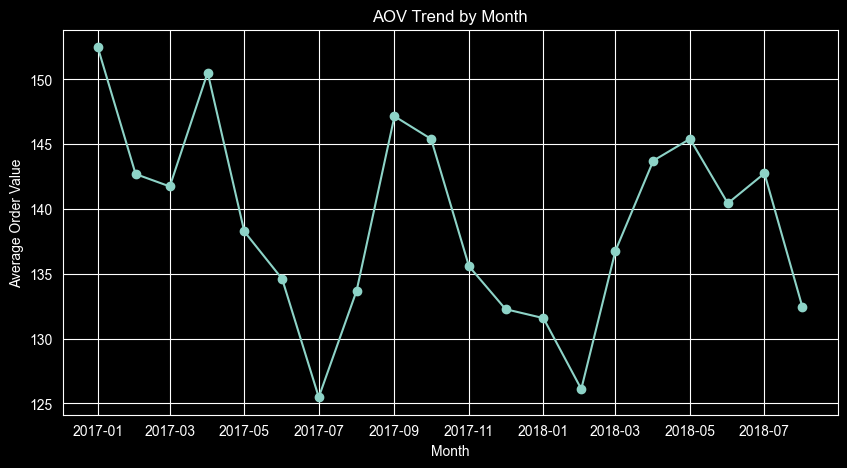

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_metrics_clean["order_month_date"], monthly_metrics_clean["aov"], marker="o")
plt.title("AOV Trend by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.show()

Для анализа динамики среднего чека исключены стартовые месяцы 2016 года, так как в них слишком мало заказов и AOV нестабилен. Основной тренд рассматривается за период с января 2017 по август 2018.

Средний чек по месяцам колеблется примерно в диапазоне 125–153. Это означает, что рост выручки в основном был связан с увеличением количества заказов, а не с ростом среднего чека.
В отдельные месяцы заметны просадки и пики AOV, которые позже можно дополнительно проверить через структуру категорий и продавцов.

In [22]:
csat_by_month = (order_items_mart.groupby("order_month_date", as_index=False).agg(csat=("positive_review", "mean")))
csat_by_month_clean = csat_by_month[(csat_by_month["order_month_date"] >= "2017-01-01") &(csat_by_month["order_month_date"] <= "2018-08-01")]

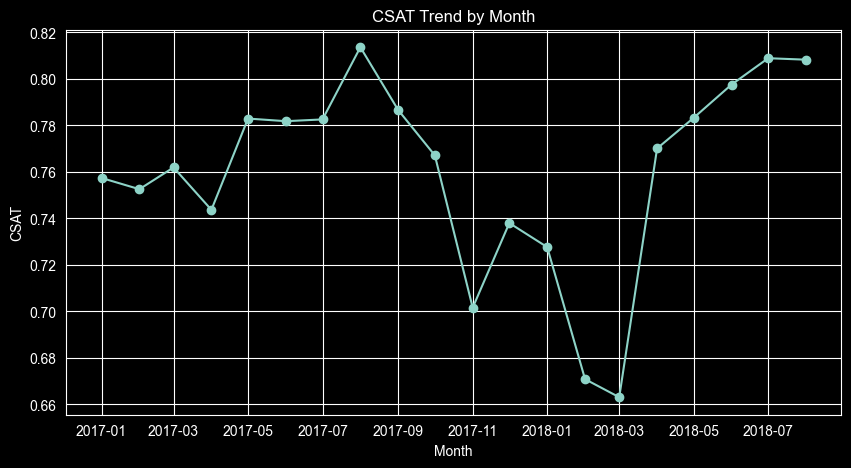

In [23]:
plt.figure(figsize=(10,5))
plt.plot(csat_by_month_clean["order_month_date"], csat_by_month_clean["csat"], marker="o")
plt.title("CSAT Trend by Month")
plt.xlabel("Month")
plt.ylabel("CSAT")
plt.show()

CSAT по месяцам заметно колеблется. В 2017 году показатель в основном держался на уровне 0.75–0.81, однако в конце 2017 - начале 2018 года наблюдается выраженное снижение удовлетворённости клиентов. Минимальное значение приходится примерно на март 2018 года.
После этого CSAT быстро восстанавливается и к лету 2018 превышает 0.80. Такой провал стоит дополнительно проверить через метрики доставки, задержек, категорий и продавцов: возможно, снижение удовлетворённости связано с ухудшением логистики или проблемами в отдельных категориях.

In [24]:
late_delivery_by_month = (order_items_mart[order_items_mart["order_status"] == "delivered"].groupby("order_month_date", as_index=False).agg(late_delivery_rate=("is_late", "mean")))
late_delivery_by_month_clean = late_delivery_by_month[(late_delivery_by_month["order_month_date"] > late_delivery_by_month["order_month_date"].min()) & (late_delivery_by_month["order_month_date"] < late_delivery_by_month["order_month_date"].max())]

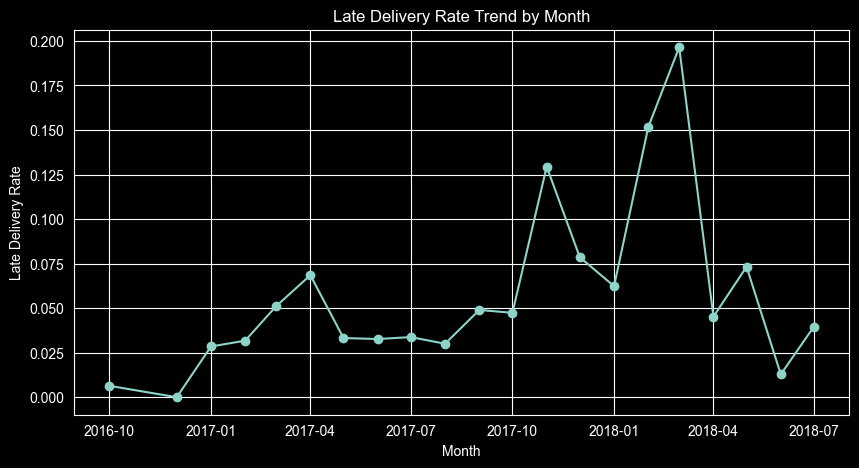

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(late_delivery_by_month_clean["order_month_date"], late_delivery_by_month_clean["late_delivery_rate"], marker="o")
plt.title("Late Delivery Rate Trend by Month")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate")
plt.show()

Доля опоздавших доставок заметно выросла в конце 2017 - начале 2018 года. Максимальное значение приходится примерно на март 2018 года, когда почти каждая пятая доставка была позже ожидаемой даты.
Этот период совпадает с провалом CSAT, поэтому задержки доставки могут быть одним из ключевых факторов снижения удовлетворённости клиентов. На следующих этапах стоит отдельно проверить связь между `delay_days`, `is_late` и `review_score`.

In [26]:
top_categories = (order_items_mart.groupby("product_category_name_english", as_index=False).agg(total_revenue=("item_total", "sum")).sort_values(by="total_revenue", ascending=False))
top_categories.head(10)

,product_category_name_english,total_revenue
44,health_beauty,1441248.07
71,watches_gifts,1305541.61
8,bed_bath_table,1241681.72
66,sports_leisure,1156656.48
16,computers_accessories,1059272.40
40,furniture_decor,902511.79
50,housewares,778397.77
21,cool_stuff,719329.95
6,auto,685384.32
43,garden_tools,584219.21


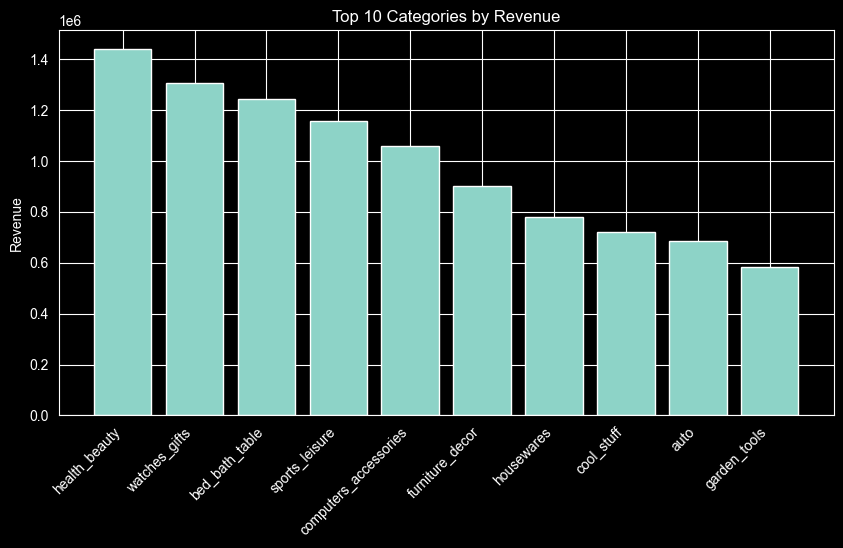

In [27]:
plt.figure(figsize=(10,5))
plt.bar(top_categories["product_category_name_english"].head(10),top_categories["total_revenue"].head(10))
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Categories by Revenue")
plt.ylabel("Revenue")
plt.show()

Наибольшую выручку приносят категории `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` и `computers_accessories`. Это ключевые категории маркетплейса с точки зрения оборота.
Выручка распределена неравномерно: первые несколько категорий заметно опережают остальные. На следующих этапах стоит дополнительно проверить не только выручку, но и CSAT, долю задержек и средний чек по этим категориям, чтобы понять, являются ли они не только крупными, но и качественными направлениями бизнеса.

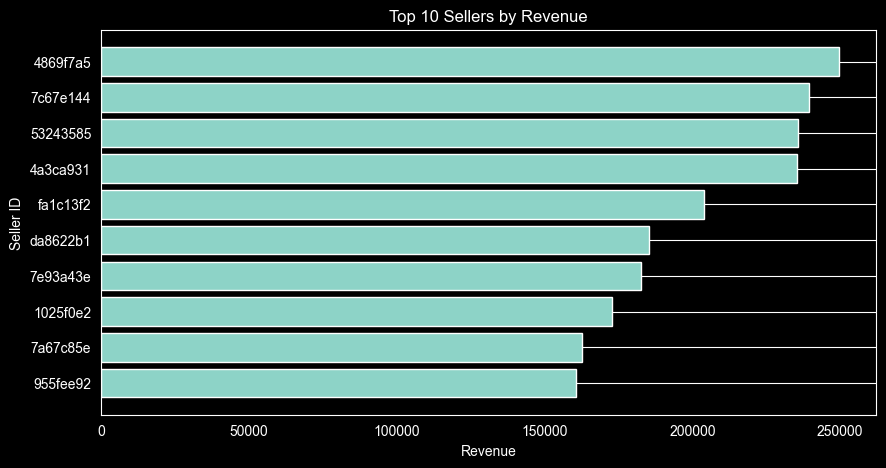

In [28]:
top_sellers = (order_items_mart.groupby("seller_id", as_index=False).agg(revenue=("item_total", "sum")).sort_values("revenue", ascending=False).head(10))
top_sellers["seller_short_id"] = top_sellers["seller_id"].str[:8]
plt.figure(figsize=(10, 5))
plt.barh(top_sellers["seller_short_id"], top_sellers["revenue"])
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

Топ-10 продавцов по выручке имеют сопоставимые значения, при этом несколько лидеров заметно опережают остальных продавцов. Это говорит о том, что часть оборота маркетплейса концентрируется у ограниченного числа продавцов.
На следующих этапах важно проверить не только выручку продавцов, но и качество их работы: среднюю оценку, долю негативных отзывов и долю опоздавших доставок.

In [29]:
top_states = (order_items_mart.groupby("customer_state", as_index=False).agg(revenue=("item_total", "sum")).sort_values("revenue", ascending=False).head(10))
top_states

,customer_state,revenue
25,SP,5921678.12
18,RJ,2129681.98
10,MG,1856161.49
22,RS,885826.76
17,PR,800935.44
4,BA,611506.67
23,SC,610213.60
6,DF,353229.44
8,GO,347706.93
7,ES,324801.91


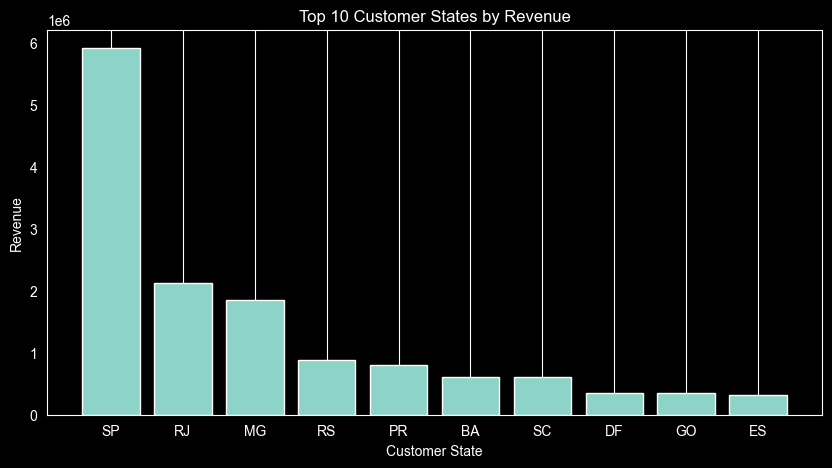

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(top_states["customer_state"], top_states["revenue"])
plt.title("Top 10 Customer States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Revenue")
plt.grid(axis="y")
plt.show()

Наибольшую выручку приносит штат `SP`, который значительно опережает остальные регионы. Далее идут `RJ` и `MG`, но их вклад заметно ниже.
Это говорит о высокой концентрации бизнеса в нескольких ключевых штатах, особенно в São Paulo. На следующих этапах стоит дополнительно проверить не только выручку по регионам, но и количество заказов, средний чек, качество доставки и CSAT по штатам.

### Основные выводы
- Маркетплейс имеет крупный объём данных: почти 99 тыс. заказов, более 95 тыс. уникальных клиентов, более 3 тыс. продавцов и почти 33 тыс. товаров.
- Большая часть заказов имеет статус `delivered`, поэтому именно доставленные заказы будут основой для дальнейшего анализа выручки, доставки и клиентского опыта.
- Общая выручка от товаров составила около 13.6 млн, а GMV с учётом доставки — около 15.8 млн. Доля доставки в GMV составляет около 14%, поэтому логистика является заметной частью стоимости заказа.
- Динамика заказов и выручки показывает активный рост в течение 2017 года и выход на высокий уровень в конце 2017 — начале 2018 года. При этом средний чек не показывает устойчивого роста, а значит рост выручки в основном связан с увеличением количества заказов.-
- Средняя оценка клиентов составляет около 4.0 из 5, а CSAT - около 75.5%. Однако доля негативных отзывов и отзывов с одной звездой остаётся заметной, поэтому клиентский опыт требует отдельного анализа.
- В конце 2017 - начале 2018 года наблюдается провал CSAT, который совпадает с ростом доли опоздавших доставок. Это указывает на возможную связь между задержками доставки и снижением удовлетворённости клиентов.
- Наибольшую выручку приносят категории `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` и `computers_accessories`. Среди регионов по выручке значительно выделяется штат `SP`, что говорит о высокой концентрации бизнеса в São Paulo.